In [ ]:
# Google Colab: execute esta célula antes de executar as demais.
%pip install -q pandas numpy matplotlib seaborn scikit-learn

# **Importando o Dataset : Breast Cancer Wisconsin**

In [1]:
import pandas as pd

df = pd.read_csv('data.csv')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


**O conjunto contém 569 amostras e 33 colunas**

In [2]:
print("Dimensões:", df.shape)

display(df.head())

print("\nInformações das colunas:")
df.info()

Dimensões: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Informações das colunas:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_s

# **Limpeza e Pré-processamento**
A base contém 569 registros e 30 atributos numéricos que
descrevem características dos núcleos celulares, além da variável diagnosis.

In [3]:
from sklearn.preprocessing import LabelEncoder

df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Converter o diagnóstico de texto para números: Maligno (M) = 1, Benigno (B) = 0
le = LabelEncoder()
y = le.fit_transform(y)

print("Dimensões tratadas:", X.shape)

Dimensões tratadas: (569, 30)


# **Distribuição dos Dados**

foram identificados 357 casos benignos e 212 casos malignos,
correspondendo a aproximadamente 62,7% e 37,3% dos registros

In [4]:
contagem = df["diagnosis"].value_counts().sort_index()

percentual = (
    df["diagnosis"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

resumo_diagnostico = pd.DataFrame({
    "quantidade": contagem,
    "percentual": percentual
})

resumo_diagnostico.index = ["Benigno (0)", "Maligno (1)"]

display(resumo_diagnostico)

,quantidade,percentual
Benigno (0),357,62.74
Maligno (1),212,37.26


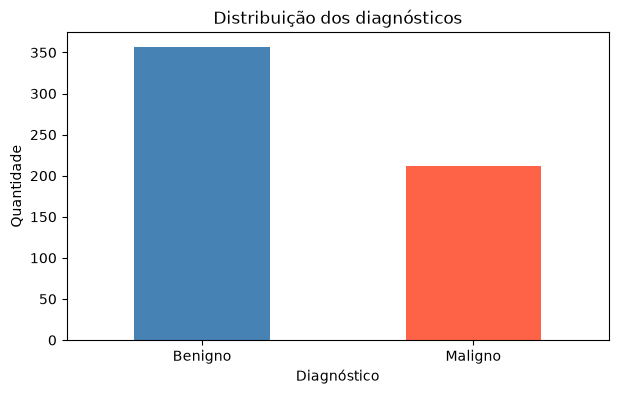

In [5]:
import matplotlib.pyplot as plt

cores = ["steelblue", "tomato"]

ax = contagem.plot(
    kind="bar",
    color=cores,
    figsize=(7, 4)
)

ax.set_title("Distribuição dos diagnósticos")
ax.set_xlabel("Diagnóstico")
ax.set_ylabel("Quantidade")
ax.set_xticklabels(["Benigno", "Maligno"], rotation=0)

plt.show()

# AVALIAR

Distribuição de dados (cont.)

Na amostra de teste,
formada por 30% dos dados, foram obtidos 108 casos benignos e 63 malignos, totalizando
171 observações e mantendo uma proporção semelhante à observada no conjunto original.
Essa distribuição reforça a necessidade de avaliar métricas específicas por classe,
especialmente recall, precision e F1-score da classe maligna, em vez de considerar apenas
a acurácia global.

# **Análise de Correlação**

calculo a matriz de correlação de Pearson entre os 30 atributos numéricos do
conjunto de dados.

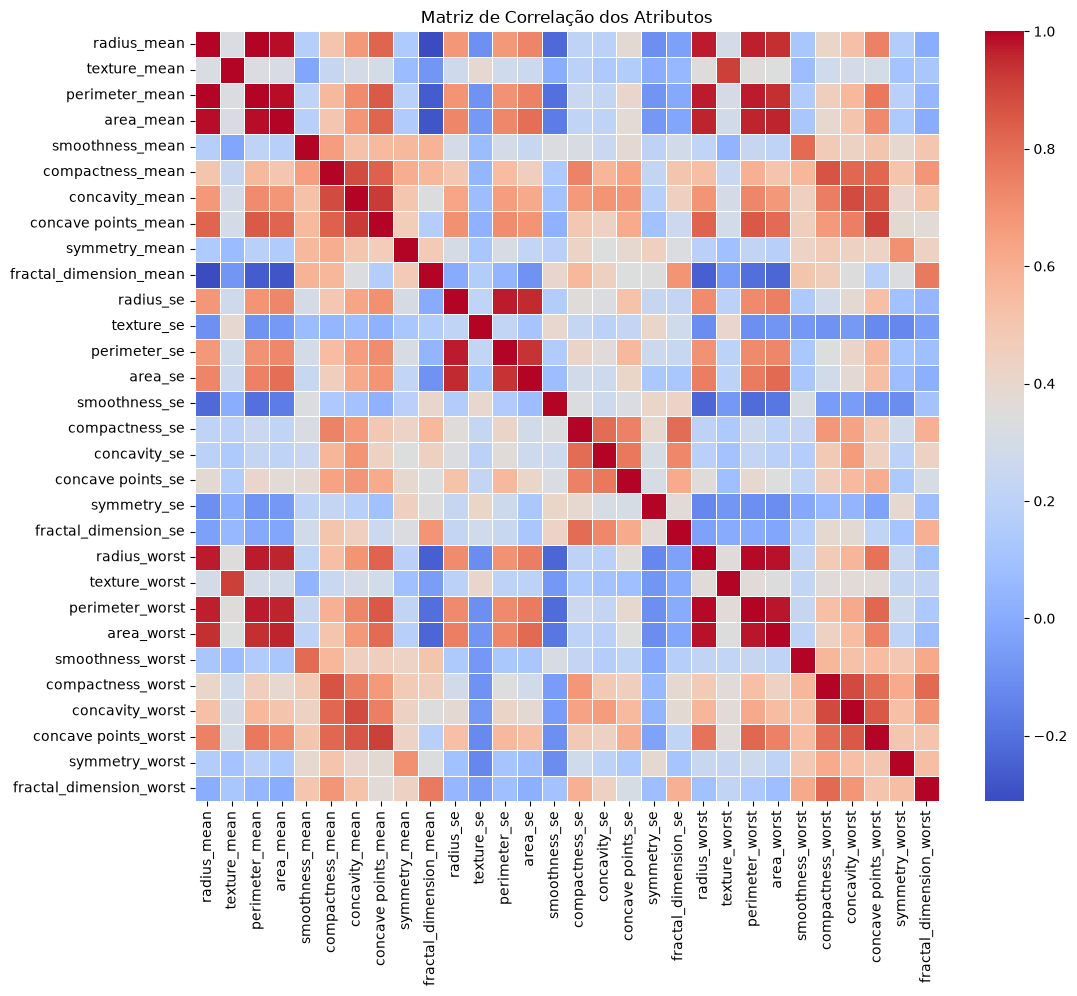

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title("Matriz de Correlação dos Atributos")
plt.show()

A visualização evidenciou correlações elevadas entre medidas
relacionadas ao tamanho e à forma dos núcleos celulares, especialmente entre atributos
como raio, perímetro e área.

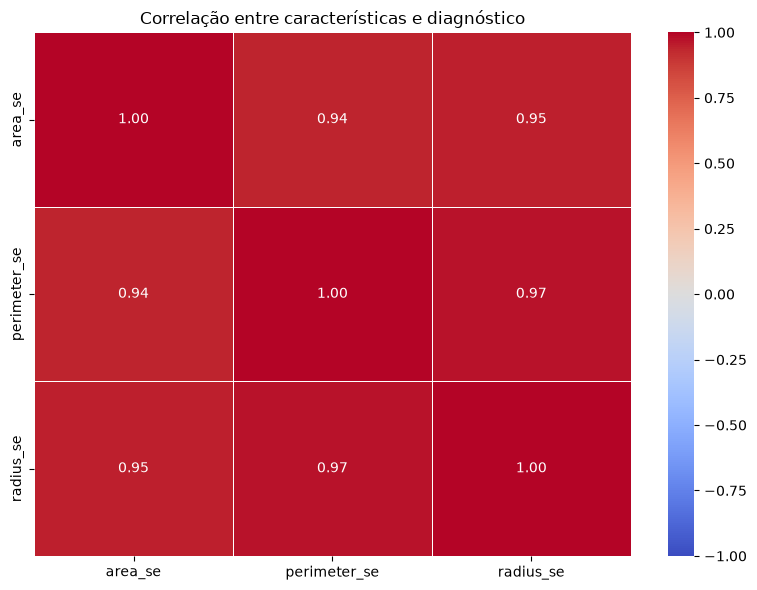

In [7]:
colunas_heatmap = [
    "area_se",
    "perimeter_se",
    "radius_se"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[colunas_heatmap].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlação entre características e diagnóstico")
plt.tight_layout()
plt.show()

Também foram observadas relações entre variáveis
associadas à concavidade e à quantidade de pontos côncavos.

# Concluímos que:

Esses resultados indicam a
presença de informações parcialmente redundantes no conjunto. Essa característica deve
ser considerada principalmente na interpretação da Regressão Logística, pois atributos
correlacionados podem distribuir entre si a influência exercida sobre a previsão. Nos
modelos baseados em árvores, como o Gradient Boosting, a correlação também pode fazer
com que a importância seja dividida entre atributos semelhantes.

# **Pré-processamento dos Dados para modelos**

398 observações foram destinadas ao treinamento e 171 ao
teste

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Divisão dos dados (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def mostrar_distribuicao(nome, valores):
    valores_series = pd.Series(valores)

    resumo = pd.DataFrame({
        "quantidade": valores_series.value_counts().sort_index(),
        "percentual": (
            valores_series.value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .round(2)
        )
    })

    resumo.index = ["Benigno (0)", "Maligno (1)"]

    print(f"\n{nome}: {len(valores)} registros")
    display(resumo)


print("X de treino:", X_train.shape)
print("X de validação:", X_test.shape)

mostrar_distribuicao("Treino", y_train)
mostrar_distribuicao("Validação", y_test)

X de treino: (398, 30)
X de validação: (171, 30)

Treino: 398 registros


,quantidade,percentual
Benigno (0),249,62.56
Maligno (1),149,37.44



Validação: 171 registros


,quantidade,percentual
Benigno (0),108,63.16
Maligno (1),63,36.84


# **Modelos Selecionados**

Foram selecionados dois classificadores supervisionados. A **Regressão Logística** que é um
modelo linear probabilístico, útil como referência por sua simplicidade e interpretabilidade, e o
**Gradient Boosting** que combina árvores de decisão de forma sequencial, corrigindo erros das
árvores anteriores e podendo capturar relações não lineares entre os atributos.


Foi aplicado StandardScaler aos atributos. O escalonador foi ajustado exclusivamente sobre
X_train e, depois, aplicado a X_test, evitando que estatísticas do conjunto de teste
influenciassem o treinamento. A padronização é especialmente importante para a
Regressão Logística, pois coloca as variáveis em escala comparável; ela também foi
mantida no fluxo do Gradient Boosting para uniformidade entre os experimentos

In [9]:
# Padronização dos dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Criação e Treinamento do Modelo Gradient Boosting**

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

# n_estimators: número de árvores
# learning_rate: o peso que cada árvore tem na correção dos erros (valores menores evitam overfitting)
# max_depth: profundidade máxima de cada árvore
modelo_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
modelo_gb.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

# **Avaliação do Modelo Gradient Boosting**

Acuracia de 95%.

**"De todas as vezes que o modelo previu que era Maligno, quantas vezes ele realmente acertou?"**

Precision de 95% nos diagnósticos malignos.

**"De todos os casos que realmente eram Malignos, quantos o modelo conseguiu encontrar?"**

Recall de 94%, Em diagnósticos médicos, um recall alto para a classe "Maligna" é fundamental para não mandar um paciente doente para casa sem tratamento.


**Média harmônica entre Precision e Recall:**

F1-score de 94%

In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = modelo_gb.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f'Acurácia do modelo Gradient Boosting: {acuracia * 100:.2f}%\n')
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=['Benigno (B)', 'Maligno (M)']))

Acurácia do modelo Gradient Boosting: 95.91%

Relatório de Classificação:
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.97      0.97       108
 Maligno (M)       0.95      0.94      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



# **Visualização da Matriz de Confusão do Gradient Boosting**

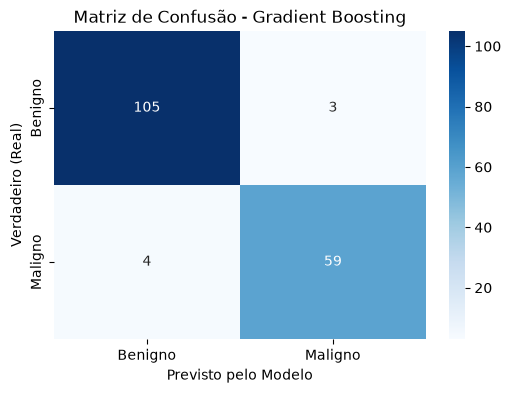

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto pelo Modelo')
plt.title('Matriz de Confusão - Gradient Boosting')
plt.show()

# **Conclusão Gradient Boosting**

O modelo Gradient Boosting está com um desempenho excelente e muito bem equilibrado. Ele não apenas tem uma precisão alta, mas também erra muito pouco ao tentar identificar a classe mais crítica (Maligna), porém ele deixa passar 4 falsos negativos o que na prática médica não é desejavel.


# **Gradient Bossting com Recall Priorizado**

In [13]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# 1. Em vez de prever a classe (0 ou 1), vamos extrair a PROBABILIDADE de ser Maligno (classe 1)
y_prob = modelo_gb.predict_proba(X_test)[:, 1]

# 2. Encontrar automaticamente o limiar (threshold) ideal para ter Recall = 1.0
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Busca o maior threshold possível que ainda mantenha o recall em 100%
# Adicionamos uma pequena margem de segurança (opcional, mas recomendado)
limiares_recall_1 = thresholds[recalls[:-1] >= 1.0]
limiar_ideal = limiares_recall_1[-1] if len(limiares_recall_1) > 0 else 0.5

print(f"Limiar padrão era: 0.500")
print(f"Novo Limiar ajustado para Recall 1.0: {limiar_ideal:.3f}\n")

# 3. Aplicar o novo limiar nas previsões
y_pred_recall_1 = (y_prob >= limiar_ideal).astype(int)

# 4. Avaliar o novo resultado
print('Novo Relatório de Classificação (Focado no Recall do Maligno):')
print(classification_report(y_test, y_pred_recall_1, target_names=['Benigno (B)', 'Maligno (M)']))

Limiar padrão era: 0.500
Novo Limiar ajustado para Recall 1.0: 0.011

Novo Relatório de Classificação (Focado no Recall do Maligno):
              precision    recall  f1-score   support

 Benigno (B)       1.00      0.89      0.94       108
 Maligno (M)       0.84      1.00      0.91        63

    accuracy                           0.93       171
   macro avg       0.92      0.94      0.93       171
weighted avg       0.94      0.93      0.93       171



# **Impacto do Ajuste**
Recall (Maligno) em 100%: O modelo agora encontra exatamente 100% dos casos que são realmente malignos no mundo real.

Precision (Maligno) caindo para 84%: Como o modelo agora classifica qualquer leve suspeita de 1,1% (limiar de 0.011) como maligno, ele começa a dar mais "falsos alarmes".

Accuracy (Acurácia) em 93%: A taxa de acertos totais caiu um pouco, de 96% para 93%. Esse é o preço matemático pago (gerando mais falsos positivos) para garantir uma detecção perfeita da doença.

# **Visualizar a nova Matriz de Confusão Gradient Boosting**

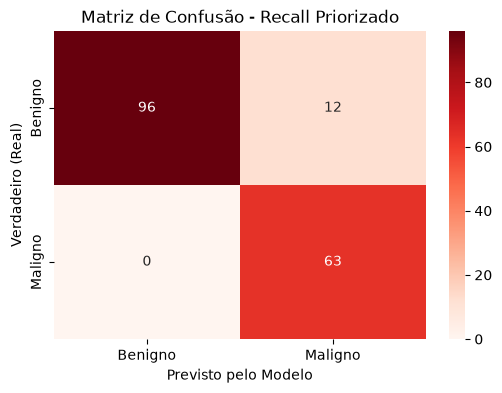

In [14]:
cm_ajustada = confusion_matrix(y_test, y_pred_recall_1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_ajustada, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto pelo Modelo')
plt.title(f'Matriz de Confusão - Recall Priorizado')
plt.show()

# **Conclusão Gradient Boosting com Recall Priorizado**

O zero absoluto aqui é o troféu dessa reavaliação. Nenhum único caso maligno real foi mandado para casa com um diagnóstico de "benigno".

Na prática médica e de diagnósticos críticos, essa configuração é geralmente a desejada. É muito mais seguro e ético pedir biópsias ou exames extras para 12 pacientes saudáveis (falso alarme) do que liberar equivocadamente um único paciente doente (falso negativo).

# **Criação e Treinamento do Modelo Regressão Logistica**

In [15]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

# **Ajuste e Avaliação do Modelo Regressão Logistica para area médica**

In [16]:
# Pegamos a probabilidade do tumor ser Maligno (classe 1)
y_prob = modelo_lr.predict_proba(X_test)[:, 1]

# Calculamos as métricas para todos os limiares (thresholds) possíveis
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Filtramos apenas os limiares que entregam 100% de Recall (1.0)
limiares_recall_1 = thresholds[recalls[:-1] >= 1.0]

# Pegamos o limite mais alto possível dentro da zona segura
limiar_ideal = limiares_recall_1[-1] if len(limiares_recall_1) > 0 else 0.5
print(f"Limiar de decisão ajustado para: {limiar_ideal:.4f} (Original era 0.5000)\n")

# Aplicação do novo limiar
y_pred_seguro = (y_prob >= limiar_ideal).astype(int)

# Avaliação e Relatórios
print('Relatório de Classificação (Regressão Logística com Recall 1.0):')
print(classification_report(y_test, y_pred_seguro, target_names=['Benigno (B)', 'Maligno (M)']))

Limiar de decisão ajustado para: 0.0731 (Original era 0.5000)

Relatório de Classificação (Regressão Logística com Recall 1.0):
              precision    recall  f1-score   support

 Benigno (B)       1.00      0.89      0.94       108
 Maligno (M)       0.84      1.00      0.91        63

    accuracy                           0.93       171
   macro avg       0.92      0.94      0.93       171
weighted avg       0.94      0.93      0.93       171



Ajuste do Limiar: reduzimos a régua de decisão de 0.500 para 0.0731. Na Regressão Logística foi preciso esse valor específico para garantir o recall máximo, enquanto o Gradient Boosting precisou descer até 0.011.

Recall (Maligno) em 100%: O objetivo clínico foi atingido com perfeição. 100% dos casos realmente malignos são detectados.

Precision (Maligno) em 84%: Para garantir a captura de todos os pacientes, o modelo aponta maligno em casos limítrofes, acertando 84% das vezes.

# **Matriz de Confusão Regressão Logistica**

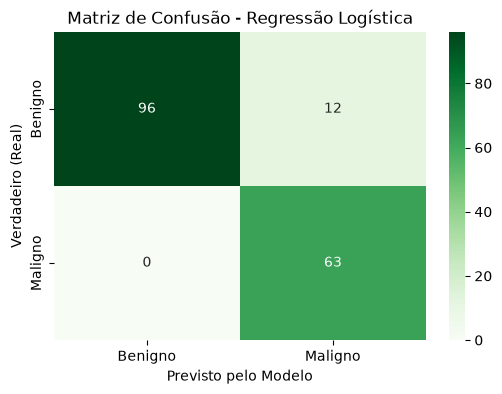

In [17]:
cm_lr = confusion_matrix(y_test, y_pred_seguro)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto pelo Modelo')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

# **Conclusão Regressão Logistica**

0 (Falsos Negativos): A métrica mais importante zerada. Nenhum paciente diagnosticado é classificado como benigno.

# **Comparação dos Modelos**

In [18]:
# Configura o pandas para não cortar o texto e respeitar quebras de linha
pd.set_option('display.max_colwidth', None)

dados_comparativos = {
    "Modelo": ["Gradient Boosting\n(limiar 0,50)", "Gradient Boosting\n(limiar 0,011)", "Regressão Logística\n(limiar 0,0731)"],
    "Acurácia": ["95,91%", "93%", "93%"],
    "Recall (M)": ["0,94", "1,0", "1,0"],
    "Precision (M)": ["0,95", "0,84", "0,84"],
    "F1 M": ["0,94", "0,91", "0,91"],
    "Observação": [
        "Melhor resultado global informado;\n4 falsos negativos.",
        "Elimina falsos negativos no teste;\naumenta falsos positivos.",
        "Prioriza recall de malignos;\nmesmo perfil do GB ajustado."
        ]
}

df_comparativo = pd.DataFrame(dados_comparativos)

# O style.set_properties ajuda a renderizar o white-space corretamente no Colab
display(df_comparativo.style.set_properties(**{'white-space': 'pre-wrap'}))

,Modelo,Acurácia,Recall (M),Precision (M),F1 M,Observação
0,"Gradient Boosting (limiar 0,50)","95,91%","0,94","0,95","0,94",Melhor resultado global informado; 4 falsos negativos.
1,"Gradient Boosting (limiar 0,011)",93%,"1,0","0,84","0,91",Elimina falsos negativos no teste; aumenta falsos positivos.
2,"Regressão Logística (limiar 0,0731)",93%,"1,0","0,84","0,91",Prioriza recall de malignos; mesmo perfil do GB ajustado.


# **Melhor Modelo**

 Com o limiar padrão de
0,50, o Gradient Boosting apresentou o melhor desempenho global. Esse resultado maior equilíbrio entre a identificação dos casos malignos e a redução de classificações incorretas.

Quando a prioridade passou a ser a identificação de todos os casos malignos, o Gradient Boosting com limiar de 0,011 e a Regressão Logística com limiar de 0,0731 apresentaram o mesmo desempenho. Portanto, nesse cenário de triagem, não foi possível indicar um único modelo como superior. A escolha deve considerar o equilíbrio desejado entre evitar falsos negativos e limitar o encaminhamento de casos benignos classificados como suspeitos.


# **Limitações**

A avaliação foi feita com uma única divisão treino/teste e sem estratificação explicitada no código, sem busca sistemática de hiperparâmetros e sem intervalo de confiança das métricas. Além disso, o limiar foi otimizado no próprio conjunto de teste, o que pode superestimar o resultado de recall; idealmente, o limiar deve ser escolhido em um conjunto separado. Os resultados também não substituem **avaliação médica** nem comprovam desempenho em populações diferentes da base estudada.

# **Aplicação no Mundo Real**

Em um contexto real, o modelo poderia atuar como apoio à triagem e à priorização de casos para revisão especializada, nunca como diagnóstico autônomo. Um fluxo seguro exigiria validação externa, monitoramento de desempenho, governança de dados, documentação das limitações e supervisão profissional. A decisão sobre o limiar deve ser definida com especialistas, pois envolve o equilíbrio entre exames adicionais desnecessários e o risco de
não identificar um caso maligno.